### **Actuarial Project: Reviewing 2014-2018 Experience to Determine the Required 2027 Rate Structure**
##### **Project Overview**
The objective of this actuarial study is to evaluate historical commercial automobile policy and claims experience from the 2014-2018 underwriting periods to determine the required overall rate change for a prospective 2027 pricing target.
##### **Objective**
This notebook integrates historical claim development, premium on-leveling, inflation trending, and operational expense strutures mathematically. By applying these parameters into fundamental ratemaking formula, this project calculates the macro-level target price direction needed to maintain corporate solvency and profitability in 2027.  
  
There are data analytic steps at the begining, 5 actuary phases and coclusion.

##### Display the number of policies and the first 5 of policies

In [2]:
import pandas as pd
import zipfile
import numpy as np

# Set the file path to the zip file
file_path = r'C:\Users\ojs64\Desktop\Study besides college\Actuary Project\Vehicle Insurance Dataset.zip'

# Read the CSV file from the zip file
with zipfile.ZipFile(file_path, 'r') as z:
    with z.open('motor_data14-2018.csv') as f:
        df = pd.read_csv(f)

# Display the number of policies
print("The number of policies is:", len(df))

# Display the first 5 policies
print("The first 5 policies are: ")
print(df.head(5))

The number of policies is: 508499
The first 5 policies are: 
   SEX INSR_BEGIN   INSR_END EFFECTIVE_YR  INSR_TYPE  INSURED_VALUE   PREMIUM  \
0    0  08-AUG-17  07-AUG-18           08       1202      519755.22   5097.83   
1    0  08-AUG-16  07-AUG-17           08       1202      519755.22   6556.52   
2    0  08-AUG-15  07-AUG-16           08       1202      519755.22   6556.52   
3    0  08-AUG-14  07-AUG-15           08       1202      519755.22   5102.83   
4    0  08-AUG-17  07-AUG-18           08       1202     1400000.00  13304.87   

    OBJECT_ID  PROD_YEAR  SEATS_NUM  CARRYING_CAPACITY TYPE_VEHICLE  CCM_TON  \
0  5000029885     2007.0        4.0                6.0      Pick-up   3153.0   
1  5000029885     2007.0        4.0                6.0      Pick-up   3153.0   
2  5000029885     2007.0        4.0                6.0      Pick-up   3153.0   
3  5000029885     2007.0        4.0                6.0      Pick-up   3153.0   
4  5000029901     2010.0        4.0                7

##### Determine total amount of premium and claim

In [3]:
#Clean the column titles
df.columns = df.columns.str.strip()

#Show the list of clean columns
print("The clean columns are:", df.columns.tolist())

#Convert the 'INSR_BEGIN' column to datetime format, handling errors by coercing invalid dates to NaT(Not Time)
df['INSR_BEGIN'] = pd.to_datetime(df['INSR_BEGIN'], errors='coerce')

#Create a new column 'Policy_Year' by "INSR_BEGIN" column's year
df['POLICY_YEAR'] = df['INSR_BEGIN'].dt.year

#Fill missing values in the 'CLAIM_PAID' column with 0
df['CLAIM_PAID'] = df['CLAIM_PAID'].fillna(0)

#Group by 'POLICY_YEAR' and aggregate the totals. rest_index() is used to convert the groupby object back to a DataFrame
summary_df = df.groupby('POLICY_YEAR').agg(
    Total_Premium=('PREMIUM', 'sum'),
    Total_Claims=('CLAIM_PAID', 'sum')
).reset_index()

# Filter the summary DataFrame to include only the years between 2014 and 2018
summary_df = summary_df[summary_df['POLICY_YEAR'].between(2014, 2018)]

# Display the summary DataFrame
print("Summary of Total Premium and Total Claims by Policy Year (2014-2018):")
print(summary_df)

The clean columns are: ['SEX', 'INSR_BEGIN', 'INSR_END', 'EFFECTIVE_YR', 'INSR_TYPE', 'INSURED_VALUE', 'PREMIUM', 'OBJECT_ID', 'PROD_YEAR', 'SEATS_NUM', 'CARRYING_CAPACITY', 'TYPE_VEHICLE', 'CCM_TON', 'MAKE', 'USAGE', 'CLAIM_PAID']
Summary of Total Premium and Total Claims by Policy Year (2014-2018):
   POLICY_YEAR  Total_Premium  Total_Claims
0         2014   5.182466e+08  1.509553e+09
1         2015   9.272150e+08  2.699013e+09
2         2016   1.046937e+09  2.666443e+09
3         2017   1.163291e+09  1.968461e+09
4         2018   3.839141e+08  3.373144e+08


C:\Users\ojs64\AppData\Local\Temp\ipykernel_12732\4176659227.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['INSR_BEGIN'] = pd.to_datetime(df['INSR_BEGIN'], errors='coerce')


##### ***Phase A:*** Loss Development  
Because the raw experience data is a static snapshot bounded between 2014 and 2018, the claim for recent periods(specifically 2017 and 2018) are not "fully cooked". In commercial auto liability, open lawsuits and ongoing medical treatment cause claims to grow significantly over time.  
To account for this maturity lag and accurately calculate Ultimate Losses, historical base loses must be multiplied by selected industry benchmark Loss Development Factors(LDFs).  
2014 LDF: 1.02  
2015: 1.05  
2016: 1.12  
2017: 1.25  
2018: 1.45  
*Source Reference: Insurance Services Office (ISO) Commercial Automobile Liability Benchmark Data / Public Rate Filings submitted to State Departments of Insurance.*  

In [4]:
# Define the benchmark LDFs for each policy year
ldf_dict = {2014: 1.02, 2015: 1.05, 2016: 1.12, 2017: 1.25, 2018: 1.45}

# Map the LDFs to existing summary table
summary_df['LDF'] = summary_df['POLICY_YEAR'].map(ldf_dict)

#Calculate the ultimate Losses
summary_df["Ultimate_Loss"] = summary_df["Total_Claims"] * summary_df["LDF"]

# Display the results
print(summary_df)

   POLICY_YEAR  Total_Premium  Total_Claims   LDF  Ultimate_Loss
0         2014   5.182466e+08  1.509553e+09  1.02   1.539744e+09
1         2015   9.272150e+08  2.699013e+09  1.05   2.833964e+09
2         2016   1.046937e+09  2.666443e+09  1.12   2.986416e+09
3         2017   1.163291e+09  1.968461e+09  1.25   2.460576e+09
4         2018   3.839141e+08  3.373144e+08  1.45   4.891059e+08


##### **Phase B:** Premium On-Leveling
Because the sourse dataset is restricted to historical periods, a market hardening senario is selected to simulate real-world premium revenue adjustements.   
  
**Assumed Fictional Company Rate Histroy:**  
**July 1, 2015:** +4.0% Overall rate increase implemented due to emerging property damage severity.  
**October 1, 2017:** +6.0% Overall rate increase implemented due to rising social inflation in bodily injury claims.  
  
Using these historical parameters, approximate On-Level Factors(OLFs) were established to adjust the premium data.
$$\text{On-Level Premium} = \text{Total Premium} \times \text{On-Level Factor (OLF)}$$


In [5]:
# Define invented On-Level Factors(OLF) based on the rate of the scenario
olf_dict = {2014: 1.102, 2015: 1.082, 2016: 1.06, 2017: 1.045, 2018: 1.00}

# Map the OLFs to summary table
summary_df['OLF'] = summary_df['POLICY_YEAR'].map(olf_dict)

# Calculate On-Level Premium (Total_Premium * OLF)
summary_df['On_Level_Premium'] = summary_df['Total_Premium'] * summary_df['OLF']

# Display the results
print(summary_df[["POLICY_YEAR", "Total_Premium", "OLF", "On_Level_Premium"]])

   POLICY_YEAR  Total_Premium    OLF  On_Level_Premium
0         2014   5.182466e+08  1.102      5.711077e+08
1         2015   9.272150e+08  1.082      1.003247e+09
2         2016   1.046937e+09  1.060      1.109753e+09
3         2017   1.163291e+09  1.045      1.215640e+09
4         2018   3.839141e+08  1.000      3.839141e+08


##### **Phase C:** Trending
The objective of Phase C is to bridge the chronological gap between historical experience period(2014-2018) and our prospective 2027 target pricing year by trending both premium and losses.  
  
**Assumptions:**
1. Policies are written evenly throughout any given calendar year. Under a standard policy year framwork, July 1st is the average purchase date of a policy of a year, and January 1st of the following year is the average accident date. By using this parameter, the trend periods($n$) are 13,12,11,10, and 9.  
2. Industry-standard Commercial Auto annual loss trend is 5.0% to account for inflation. 
$$\text{Trended Ultimate Loss} = \text{Ultimate Loss} \times (1 + \text{Annual Loss Trend Rate})^n$$

In [6]:
# Define the trend periods(n) for each policy year to Jan 1, 
trend_periods = {2014: 13, 2015: 12, 2016: 11, 2017: 10, 2018: 9}

# Set the annual trend rate as 5%
annual_trend_rate = 0.05

# Calculate the trend factors for each year
trend_factor_dict = {
    year: (1+annual_trend_rate) ** n for year, n in trend_periods.items()
}

# Map the trend factors onto the summary table
summary_df["Loss_Trend_Factor"] = summary_df["POLICY_YEAR"].map(trend_factor_dict)

# Calculate the Trend Adjusted Ultimate Losses
summary_df["Trend_Adjusted_Ultimate_Loss"] = summary_df["Ultimate_Loss"] * summary_df["Loss_Trend_Factor"]

# Display the result
print(summary_df[["POLICY_YEAR", "Total_Premium", "Ultimate_Loss", "Loss_Trend_Factor", "Trend_Adjusted_Ultimate_Loss"]])



   POLICY_YEAR  Total_Premium  Ultimate_Loss  Loss_Trend_Factor  \
0         2014   5.182466e+08   1.539744e+09           1.885649   
1         2015   9.272150e+08   2.833964e+09           1.795856   
2         2016   1.046937e+09   2.986416e+09           1.710339   
3         2017   1.163291e+09   2.460576e+09           1.628895   
4         2018   3.839141e+08   4.891059e+08           1.551328   

   Trend_Adjusted_Ultimate_Loss  
0                  2.903417e+09  
1                  5.089392e+09  
2                  5.107785e+09  
3                  4.008019e+09  
4                  7.587638e+08  


##### **Phase D:** Expenses, Profit, and ULAE
To protect company solvency, the final 2027 premium must generate sufficient revenue to fund ongoing corporate overhead, internal claims departments, and investors' capital requirements.  
  
**Unallocated Loss Adjustment Expenses(ULAE):** Set as 5%. ULAE represents the internal overhead cost of maintaining a claim department (such as office space and claim adjusters' salary) that cannot be traced to a single, specific accident file. This factor is applied directly to Trended Ultimate Losses to calculate total Trended Loss and LAE.    
**Variable expense ratio:** Set as 15%. Variable expense includes agent commissions, state premium taxes, and underwriting licenses.  
**Fixed expense ratio** is set to 10%. Fixed expense includes general administrative overhead, internal IT systems, and buillding rent.  
**Target profit provision** is set to 5%. This is the necessary safety margin set ratio.  


In [7]:
# Define the ULAE factor, variable expense ratio, fixed expense ratio, target profit margin
ULAE = 1.05
Variable_Expense_Ratio = 0.15
Fixed_Expense_Ratio = 0.10
Target_Profit_Margin = 0.05

# Calculate the Trended Loss and LAE by multiplying the Trend Adjusted Ultimate Losses by the ULAE factor
summary_df["Trended_Loss_and_LAE"] = summary_df["Trend_Adjusted_Ultimate_Loss"] * ULAE

# Display the result
print(summary_df[["POLICY_YEAR", "On_Level_Premium", "Trend_Adjusted_Ultimate_Loss", "Trended_Loss_and_LAE"]])

   POLICY_YEAR  On_Level_Premium  Trend_Adjusted_Ultimate_Loss  \
0         2014      5.711077e+08                  2.903417e+09   
1         2015      1.003247e+09                  5.089392e+09   
2         2016      1.109753e+09                  5.107785e+09   
3         2017      1.215640e+09                  4.008019e+09   
4         2018      3.839141e+08                  7.587638e+08   

   Trended_Loss_and_LAE  
0          3.048588e+09  
1          5.343862e+09  
2          5.363174e+09  
3          4.208420e+09  
4          7.967020e+08  


##### **Phase E:** Indicator Calculation
The final phase brings together all the developed, on-leveled, and trended matrics to compute the final required rate movement for the 2027 pricing target.  
  
**Projected Loss & LAE ratio:** Calculated by dividing the heavily inflated 2027 total claim costs by the adjusted baseline corporate revenue.
**The Indicated Rate Change:** Determined using the standard CAS corporate equation, which loads the projected loss ratio to account for fixed overhead, variable expenses, and the target profit margin.  
$$\text{Projected Loss \& LAE Ratio} = \frac{\text{Trended Loss \& LAE}}{\text{On-Level Premium}}$$

$$\text{Indicated Rate Change} = \frac{\text{Projected Loss \& LAE Ratio} + \text{Fixed Expense Ratio}}{1 - \text{Variable Expense Ratio} - \text{Target Profit Margin}} - 1$$


In [10]:
# Calculate the projected loss ratio by dividing the Trended Loss and LAE by the On-Level Premium
summary_df["Projected_Loss_Ratio"] = summary_df["Trended_Loss_and_LAE"] / summary_df["On_Level_Premium"]

# Calculate the average of projected loss ratio to smooth out volatility
Avg_Projected_Loss_Ratio = summary_df["Projected_Loss_Ratio"].mean()

# Calculate the indicated rate change
indicated_rate_change = (Avg_Projected_Loss_Ratio + Fixed_Expense_Ratio) / (1- Variable_Expense_Ratio - Target_Profit_Margin)-1

# Display the results
print("FINAL 2027 COMMERCIAL AUTO RATE INDICATION")
print(f"Weighted Multi-Year Projected Loss & LAE Ratio: {Avg_Projected_Loss_Ratio:.2%}")
print(f"Fixed Expense Provision:                       {Fixed_Expense_Ratio:.2%}")
print(f"Variable Expense & Profit Target:             {1.0 - (Variable_Expense_Ratio + Target_Profit_Margin):.2%}")
print("-" * 60)
print(f"FINAL INDICATED 2027 RATE CHANGE:             {indicated_rate_change:.2%}")
print("=" * 60)

FINAL 2027 COMMERCIAL AUTO RATE INDICATION
Weighted Multi-Year Projected Loss & LAE Ratio: 420.69%
Fixed Expense Provision:                       10.00%
Variable Expense & Profit Target:             80.00%
------------------------------------------------------------
FINAL INDICATED 2027 RATE CHANGE:             438.36%


##### **Conclusion**
Based on the final output, the portfolio requires a final indicated 2027 rate change of +438.36%. This magnitude means that the company's current rate structure is severely deficient. To cover projected 2027 claims, premium rates would theoretically need to be increased by more than 5 times their current levels. The most significant reason of the massive rate deficiency is 9 to 13 year of gaps from the period of given data(2014-2018) and target year(2027).  
  
2014 losses are multiplied by 1.886 and 2018 losses are multiplied by 1.551. When the historical claims are amplified exponentially by compounding inflation while the historical premium revenue baseline remains relatively flat, the projected loss ratio expand dramatically. The following code shows a plot of Loss Trend Factor and On-Level Factor.  
$$\text{Trended Loss \& LAE} = \text{Trended Ultimate Loss} \times 1.05$$


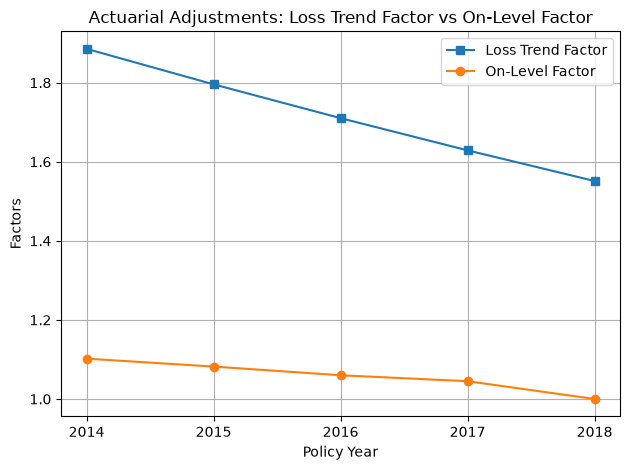

In [9]:
import matplotlib.pyplot as plt

# Generate arrays of policy year from 2014 t0 2018, Loss Trend Factor, and On-Level Factor
policy_years = np.array(summary_df['POLICY_YEAR'].values)
loss_trend_factors = np.array(summary_df['Loss_Trend_Factor'].values)
on_level_factors = np.array(summary_df['OLF'].values)

# Plot the Loss Trend Factor and On-Level Factor against Policy Year
plt.plot(policy_years, loss_trend_factors, marker='s', label='Loss Trend Factor')
plt.plot(policy_years, on_level_factors, marker='o', label='On-Level Factor')

# Add labels and title
plt.xlabel('Policy Year')
plt.ylabel('Factors')
plt.title('Actuarial Adjustments: Loss Trend Factor vs On-Level Factor')

plt.xticks(np.arange(2014, 2019, 1))  # Set x-ticks for each policy year    

# Add background grid and legend
plt.grid()
plt.legend()

# Adjust layout to prevent clipping of labels and title
plt.tight_layout()  

# Show the plot
plt.show() 

The Weight Multi-year Project Loss & LAE Ratio of 420.69% indicates that for every $1 of baseline premium the company earns at current rates, it is protected to pay out $4.21 purely in claims and internal claim adjusting operations in the year 2027. The company require 10% of every premium dollar for fixed cost and 15% of for variable cost, along with 5% target profit margin.  
While 438.36% rate increase is mathematically justified by the historical flat-file simple data, excuting +400% rate hike in a real commercial insurance market is impossible. It would trigger to policyholders to cancel their policy. 
